# Image Classification on CIFAR-100: ResNet vs EfficientNet vs ViT

This notebook trains and evaluates three architectures on **CIFAR-100**:

- **ResNet-18** (CNN)
- **EfficientNet-B0** (CNN)
- **ViT-B/16** (Vision Transformer)

All models use ImageNet-pretrained weights and are fine-tuned on CIFAR-100.
CIFAR-100 images are only 32x32, so we upsample them to 224x224 to match what
the pretrained backbones expect. For each model we report **accuracy,
precision, recall, F1-score (macro & weighted)**, a full **classification
report**, and a **confusion matrix**.

> **Tip:** Run this on a GPU (Colab/Kaggle/local CUDA). Upsampling 32x32 images
> to 224x224 makes CIFAR-100 noticeably heavier to train than its native
> resolution — a GPU is strongly recommended, especially for ViT.


## 1. Setup & Installs

In [1]:
# Uncomment if running in a fresh environment (e.g. Colab)
# !pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm pandas


In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    vit_b_16, ViT_B_16_Weights,
)

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Load CIFAR-100

`torchvision.datasets.CIFAR100` downloads the dataset automatically (~170 MB).
It already ships with a standard 50,000/10,000 train/test split; we carve out
a validation set from the training split. Images are resized from 32x32 to
224x224 and normalized with ImageNet statistics (required for the pretrained
backbones).


In [3]:
DATA_ROOT = "./data"
os.makedirs(DATA_ROOT, exist_ok=True)

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two copies of the training set with different transforms (train-aug vs eval-clean),
# so we can split indices once and reuse them for both.
train_full_aug = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=train_transform)
train_full_eval = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=eval_transform)
test_ds = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_transform)

class_names = train_full_aug.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Train+Val pool size: {len(train_full_aug)} | Test size: {len(test_ds)}")


Files already downloaded and verified


D:\CODE\Thesis\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
Number of classes: 100
Train+Val pool size: 50000 | Test size: 10000


In [4]:
from torch.utils.data import Subset

# Carve out 10% of the training pool as a validation set
n_total = len(train_full_aug)
indices = list(range(n_total))
random.shuffle(indices)
n_val = int(0.10 * n_total)

val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_ds = Subset(train_full_aug, train_idx)   # augmented transform
val_ds = Subset(train_full_eval, val_idx)      # clean transform

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

BATCH_SIZE = 128
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


Train: 45000 | Val: 5000 | Test: 10000


## 3. Model Builders

Each model is loaded with ImageNet-pretrained weights and its final
classification layer is replaced to output `num_classes` (100) logits.


In [5]:
def build_model(name: str, num_classes: int) -> nn.Module:
    name = name.lower()

    if name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif name == "vit_b_16":
        weights = ViT_B_16_Weights.DEFAULT
        model = vit_b_16(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {name}")

    return model.to(device)


## 4. Training & Evaluation Utilities

`train_model` fine-tunes for a given number of epochs and tracks the best
validation accuracy checkpoint. `evaluate_model` computes accuracy,
precision/recall/F1 (macro & weighted), a full classification report,
and a confusion matrix on the test set.


In [6]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{epochs} - train"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ---- Validate ----
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} "
              f"- train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, test_loader, class_names, model_name="model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc=f"[{model_name}] evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0)

    print(f"\n=== {model_name} Test Metrics ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {precision_macro:.4f}")
    print(f"Recall (macro):      {recall_macro:.4f}")
    print(f"F1-score (macro):    {f1_macro:.4f}")
    print(f"Precision (weighted):{precision_weighted:.4f}")
    print(f"Recall (weighted):   {recall_weighted:.4f}")
    print(f"F1-score (weighted): {f1_weighted:.4f}\n")

    report = classification_report(
        all_labels, all_preds, target_names=class_names, zero_division=0
    )
    print(report)

    metrics = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "y_true": all_labels,
        "y_pred": all_preds,
        "report": report,
    }
    return metrics


def plot_confusion_matrix(y_true, y_pred, class_names, model_name="model", max_labels_shown=30):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    # With 100 classes a full label set is unreadable; show ticks only if class count is small
    show_labels = len(class_names) <= max_labels_shown
    sns.heatmap(cm, cmap="viridis",
                xticklabels=class_names if show_labels else False,
                yticklabels=class_names if show_labels else False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def plot_training_curves(history, model_name="model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", color="green")
    axes[1].set_title(f"{model_name} - Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 5. Training Configuration

Adjust `EPOCHS` based on your compute budget. CIFAR-100 has 100 fine-grained
classes, so a few more epochs than a coarser dataset can help, especially
for ViT.


In [7]:
EPOCHS = 10
LR = 1e-4

all_results = {}   # model_name -> metrics dict
all_histories = {} # model_name -> training history


## 6. ResNet-18

In [8]:
resnet_model = build_model("resnet18", num_classes)
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="ResNet18"
)
all_histories["ResNet18"] = resnet_history


[ResNet18] Epoch 1/10 - train:   0%|          | 0/352 [00:04<?, ?it/s]

[ResNet18] Epoch 1/10 - train_loss: 2.0049 - val_loss: 1.0881 - val_acc: 0.7124


[ResNet18] Epoch 2/10 - train:   0%|          | 0/352 [00:04<?, ?it/s]

[ResNet18] Epoch 2/10 - train_loss: 0.8830 - val_loss: 0.8318 - val_acc: 0.7660


[ResNet18] Epoch 3/10 - train:   0%|          | 0/352 [00:04<?, ?it/s]

...

[ResNet18] Epoch 8/10 - train_loss: 0.1412 - val_loss: 0.6297 - val_acc: 0.8174


[ResNet18] Epoch 9/10 - train:   0%|          | 0/352 [00:04<?, ?it/s]

[ResNet18] Epoch 9/10 - train_loss: 0.1197 - val_loss: 0.6268 - val_acc: 0.8214


[ResNet18] Epoch 10/10 - train:   0%|          | 0/352 [00:04<?, ?it/s]

[ResNet18] Epoch 10/10 - train_loss: 0.1101 - val_loss: 0.6244 - val_acc: 0.8206


[ResNet18] evaluating:   0%|          | 0/157 [00:04<?, ?it/s]


=== ResNet18 Test Metrics ===
Accuracy:            0.8263
Precision (macro):   0.8286
Recall (macro):      0.8263
F1-score (macro):    0.8266
Precision (weighted):0.8286
Recall (weighted):   0.8263
F1-score (weighted): 0.8266

               precision    recall  f1-score   support

        apple       0.96      0.91      0.93       100
aquarium_fish       0.96      0.91      0.93       100
         baby       0.70      0.71      0.71       100
         bear       0.73      0.72      0.73       100
       beaver       0.63      0.75      0.68       100
          bed       0.88      0.76      0.82       100
          bee       0.91      0.90      0.90       100
       beetle       0.87      0.85      0.86       100
      bicycle       0.97      0.95      0.96       100
       bottle       0.92      0.94      0.93       100
         bowl       0.67      0.65      0.66       100
          boy       0.57      0.60      0.59       100
       bridge       0.85      0.90      0.87       100
 

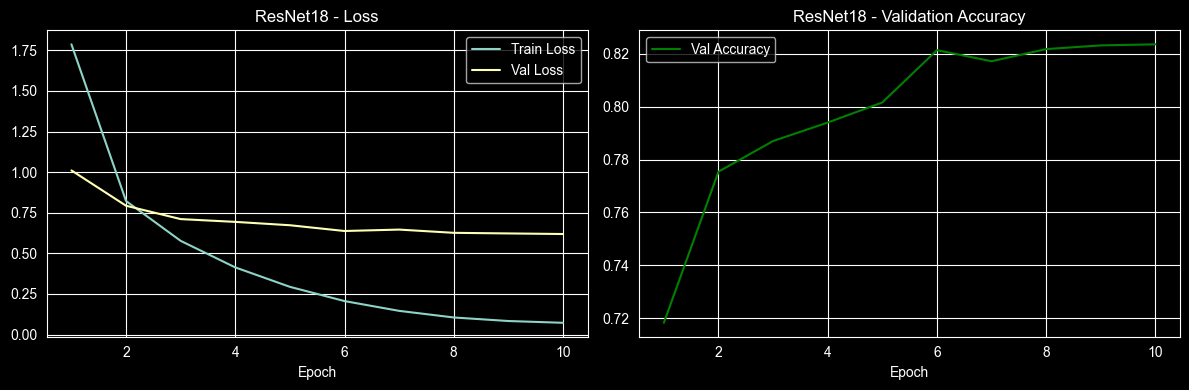

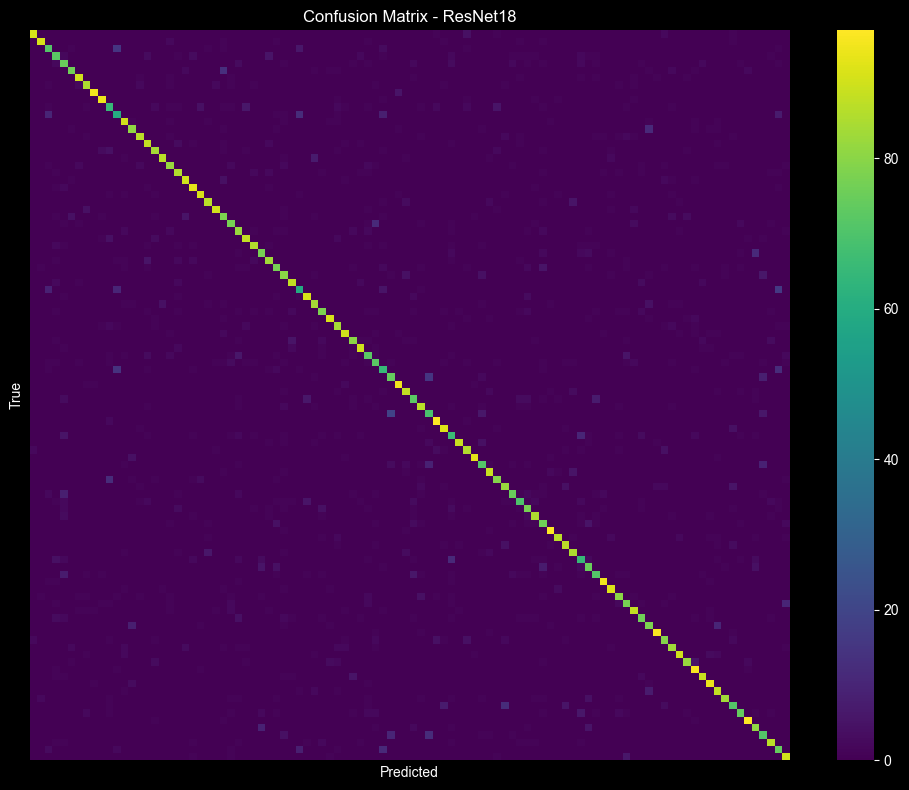

In [9]:
resnet_metrics = evaluate_model(resnet_model, test_loader, class_names, model_name="ResNet18")
all_results["ResNet18"] = resnet_metrics
plot_training_curves(resnet_history, "ResNet18")
plot_confusion_matrix(resnet_metrics["y_true"], resnet_metrics["y_pred"], class_names, "ResNet18")


## 7. EfficientNet-B0

In [10]:
effnet_model = build_model("efficientnet_b0", num_classes)
effnet_model, effnet_history = train_model(
    effnet_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="EfficientNet-B0"
)
all_histories["EfficientNet-B0"] = effnet_history


[EfficientNet-B0] Epoch 1/10 - train:   0%|          | 0/704 [00:04<?, ?it/s]

[EfficientNet-B0] Epoch 1/10 - train_loss: 2.1277 - val_loss: 0.8940 - val_acc: 0.7478


[EfficientNet-B0] Epoch 2/10 - train:   0%|          | 0/704 [00:04<?, ?it/s]

[EfficientNet-B0] Epoch 2/10 - train_loss: 0.8385 - val_loss: 0.6630 - val_acc: 0.8086


[EfficientNet-B0] Epoch 3/10 - train:   0%|          | 0/704 [00:04<?, ?it/s]

...

[EfficientNet-B0] Epoch 8/10 - train_loss: 0.2461 - val_loss: 0.5156 - val_acc: 0.8492


[EfficientNet-B0] Epoch 9/10 - train:   0%|          | 0/704 [00:04<?, ?it/s]

[EfficientNet-B0] Epoch 9/10 - train_loss: 0.2263 - val_loss: 0.5096 - val_acc: 0.8484


[EfficientNet-B0] Epoch 10/10 - train:   0%|          | 0/704 [00:04<?, ?it/s]

[EfficientNet-B0] Epoch 10/10 - train_loss: 0.2181 - val_loss: 0.5130 - val_acc: 0.8514


[EfficientNet-B0] evaluating:   0%|          | 0/157 [00:04<?, ?it/s]


=== EfficientNet-B0 Test Metrics ===
Accuracy:            0.8472
Precision (macro):   0.8500
Recall (macro):      0.8472
F1-score (macro):    0.8475
Precision (weighted):0.8500
Recall (weighted):   0.8472
F1-score (weighted): 0.8475

               precision    recall  f1-score   support

        apple       0.92      0.96      0.94       100
aquarium_fish       0.91      0.92      0.92       100
         baby       0.79      0.67      0.72       100
         bear       0.73      0.86      0.79       100
       beaver       0.64      0.76      0.69       100
          bed       0.87      0.81      0.84       100
          bee       0.89      0.89      0.89       100
       beetle       0.85      0.86      0.86       100
      bicycle       0.96      0.92      0.94       100
       bottle       0.94      0.93      0.93       100
         bowl       0.79      0.71      0.75       100
          boy       0.62      0.61      0.62       100
       bridge       0.94      0.91      0.92     

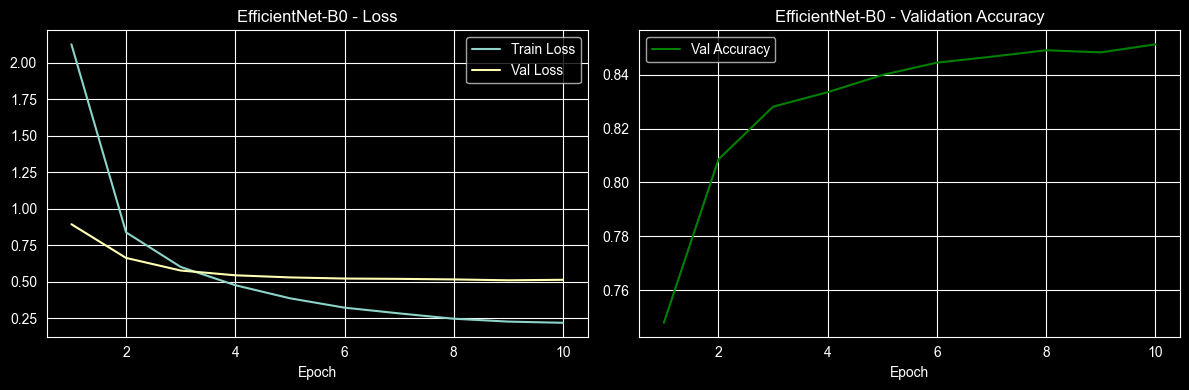

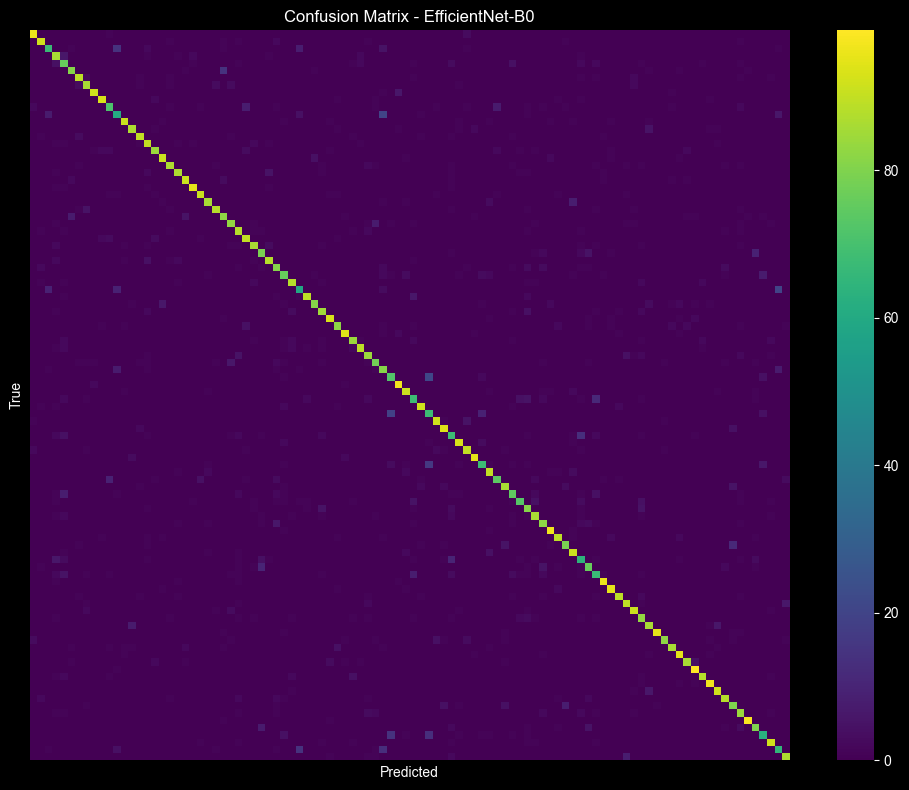

In [11]:
effnet_metrics = evaluate_model(effnet_model, test_loader, class_names, model_name="EfficientNet-B0")
all_results["EfficientNet-B0"] = effnet_metrics
plot_training_curves(effnet_history, "EfficientNet-B0")
plot_confusion_matrix(effnet_metrics["y_true"], effnet_metrics["y_pred"], class_names, "EfficientNet-B0")


## 8. Vision Transformer (ViT-B/16)

In [ ]:
vit_model = build_model("vit_b_16", num_classes)
vit_model, vit_history = train_model(
    vit_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="ViT-B/16"
)
all_histories["ViT-B/16"] = vit_history


[ViT-B/16] Epoch 1/10 - train:   0%|          | 0/352 [00:05<?, ?it/s]

In [ ]:
vit_metrics = evaluate_model(vit_model, test_loader, class_names, model_name="ViT-B/16")
all_results["ViT-B/16"] = vit_metrics
plot_training_curves(vit_history, "ViT-B/16")
plot_confusion_matrix(vit_metrics["y_true"], vit_metrics["y_pred"], class_names, "ViT-B/16")


## 9. Model Comparison

Side-by-side comparison of all metrics across the three architectures.


In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": m["accuracy"],
        "Precision (macro)": m["precision_macro"],
        "Recall (macro)": m["recall_macro"],
        "F1 (macro)": m["f1_macro"],
        "Precision (weighted)": m["precision_weighted"],
        "Recall (weighted)": m["recall_weighted"],
        "F1 (weighted)": m["f1_weighted"],
    }
    for name, m in all_results.items()
])

comparison_df = comparison_df.set_index("Model").round(4)
comparison_df


In [ ]:
# Bar chart comparing macro F1 / accuracy across models
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[["Accuracy", "F1 (macro)", "F1 (weighted)"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model Comparison on CIFAR-100")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Notes & Next Steps

- **Increase `EPOCHS`** for better convergence, especially for ViT which often needs more fine-tuning steps.
- CIFAR-100 images are small (32x32); upsampling to 224x224 costs compute but is
  needed to reuse ImageNet-pretrained weights. If speed matters more than accuracy,
  consider training from scratch at native 32x32 resolution with a smaller custom CNN instead.
- Try **freezing early layers** and only fine-tuning the head first, then unfreezing for a few more epochs (progressive unfreezing).
- For a more rigorous comparison, use **k-fold cross-validation** instead of a single train/val/test split.
- Save the best models with `torch.save(model.state_dict(), "model_name.pt")` if you want to reuse them later.
- If GPU memory is limited, reduce `BATCH_SIZE` or use gradient accumulation.
